# Notebook 6: Compare synthetic BTs with Modis observations

## Imports

In [1]:
import glob
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyhdf.SD import SD, SDC
from pyresample import create_area_def
from satpy import Scene

warnings.filterwarnings("ignore")

In [2]:
out_dir = "./plots/"

## Some functions

In [3]:
def enhanced_colormap(vmin, vmed, vmax):
    n = 256
    frac = (vmed - vmin) / (vmax - vmin)

    n_color = int(n * frac)
    n_gray = n - n_color

    colors = np.vstack([
        plt.cm.Spectral(np.linspace(0, 0.95, n_color)),
        plt.cm.gray_r(np.linspace(0, 1, n_gray)),
    ])

    return mcolors.LinearSegmentedColormap.from_list(
        "enhanced_colormap",
        colors,
    )

In [4]:
def get_boundaries(full_name, dx=1.2):
    ds = xr.open_dataset(full_name, engine="netcdf4")

    lonmin = ds.Longitude.min().values - dx
    lonmax = ds.Longitude.max().values + dx
    latmin = ds.Latitude.min().values - dx
    latmax = ds.Latitude.max().values + dx

    return lonmin, lonmax, latmin, latmax

In [5]:
def plot_overpass(scn):
    data = scn["31"] - 273

    fig, ax = plt.subplots(
        figsize=(10, 8),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )

    data.plot.imshow(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="inferno",
    )

    ax.coastlines(resolution="10m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.LAKES, facecolor="lightblue")

    ax.set_title(f"Overpass start: {scn.start_time}")

    plt.show()

In [6]:
def process_overpass(
    filename,
    channel="31",
    dx=1.0,
    target_lat=56.5,
    target_lon=-113.5,
    want2plot=True,
):
    lonmin, lonmax, latmin, latmax = get_boundaries(filename, dx=dx)

    if (
        target_lat < latmin
        or target_lat > latmax
        or target_lon < lonmin
        or target_lon > lonmax
    ):
        print("Satellite swath did not hit target region")
        return None

    scn = Scene(
        reader="modis_l1b",
        filenames=[filename],
    )

    print(scn.start_time)

    scn.load([channel])

    area_def = create_area_def(
        "modis_map",
        projection="EPSG:4326",
        area_extent=(lonmin, latmin, lonmax, latmax),
        resolution=0.01,
    )

    scn_resampled = scn.resample(area_def)

    if want2plot:
        plot_overpass(scn_resampled)

    return scn_resampled

## Get and prepare data

In [7]:
grid = xr.open_mfdataset("./data/grids/hra_DOM01.nc", engine = 'netcdf4')
lon = np.rad2deg(grid.clon)
lat = np.rad2deg(grid.clat)

path_fires = "./data/modis/modis_regridded.nc" 

fires  = xr.open_mfdataset(path_fires, engine='netcdf4')


In [8]:
threshold = 1000

var = fires.frp.sel(time=np.datetime64("2025-05-30 00:00:00"), method = "nearest") 
mask = (var >= threshold).compute()
fires_f = mask * var

fire_lons = lon.where(mask, drop = True)
fire_lats = lat.where(mask, drop = True)

2025-05-30 03:30:00


shape found from radius and resolution does not contain only integers: (2372.019577026839, 4200.76141357207)
Rounding shape to (2373, 4201) and resolution from (0.010000000000005116, 0.00999999999999801) meters to (0.009999432072302354, 0.00999586842404706) meters


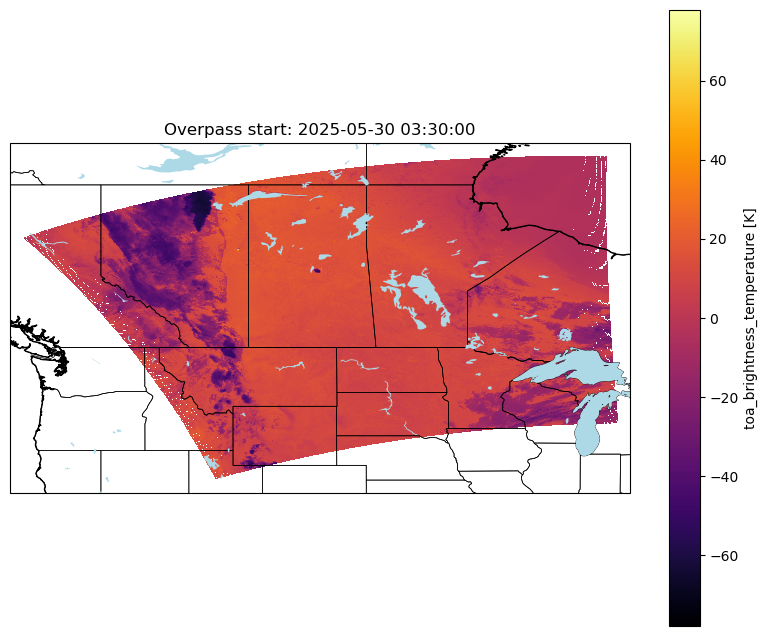

shape found from radius and resolution does not contain only integers: (2546.0945129381507, 7653.051757808585)
Rounding shape to (2547, 7654) and resolution from (0.010000000000005116, 0.010000000000005116) meters to (0.009998761115511498, 0.009996444887865934) meters


2025-05-30 03:35:00


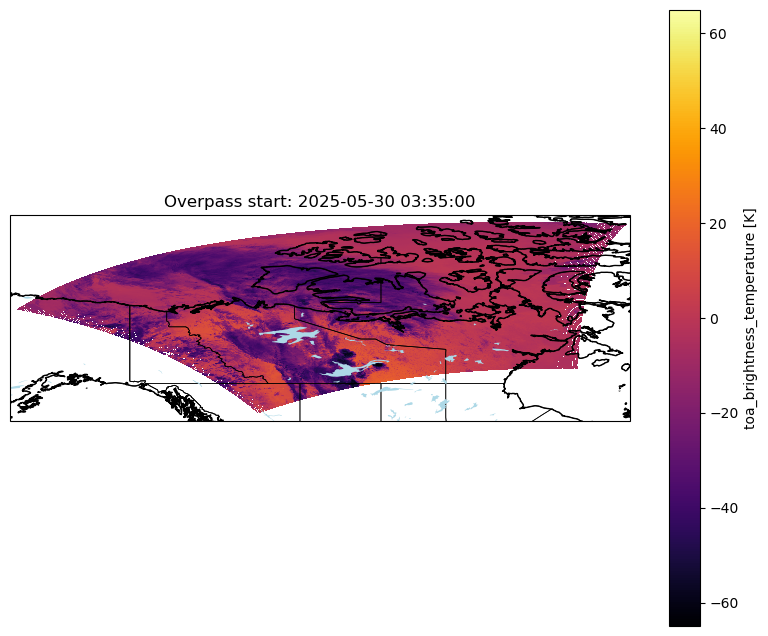

In [9]:
fnames = sorted(glob.glob("./data/modis/*.hdf"))

scenes = [process_overpass(file) for file in fnames]

In [10]:
scene1 = scenes[0].to_xarray()
scene2 = scenes[1].to_xarray()

In [11]:
prefix = "./data/synsat/lam_hra_2025_synsat_20250530T0300Z_"
suffix = ".nc"

syn1 = xr.open_dataset(prefix + "E25" + suffix, engine="netcdf4").squeeze()
syn2 = xr.open_dataset(prefix + "E27" + suffix, engine="netcdf4").squeeze()
syn3 = xr.open_dataset(prefix + "E23" + suffix, engine="netcdf4").squeeze()
syn4 = xr.open_dataset(prefix + "E31" + suffix, engine="netcdf4").squeeze()
syn5 = xr.open_dataset(prefix + "E28" + suffix, engine="netcdf4").squeeze()
syn6 = xr.open_dataset(prefix + "E29" + suffix, engine="netcdf4").squeeze()

In [12]:
d = -2
lon_max = lon.max().values + d +1
lat_max = lat.max().values + d +1
lon_min = lon.min().values - d +1
lat_min = lat.min().values - d +1


## Plot data

In [13]:
# -------------------------------------------------
# Plot settings
# -------------------------------------------------
fs = 14

figsize = (16, 10)

# Brightness temperature conversion
kelvin_to_celsius = 273.15


# Brightness temperature range
vmin = -63 + kelvin_to_celsius
vmed = -33 + kelvin_to_celsius
vmax = 35 + kelvin_to_celsius

levels = np.linspace(vmin, vmax, 201)
cmap = enhanced_colormap(vmin, vmed, vmax)

# Map
map_projection = ccrs.PlateCarree()
coastline_resolution = "10m"
coastline_linewidth = 1
border_linewidth = 0.5
state_linewidth = 0.5

# Fire locations
fire_color = "red"
fire_size = 1

# Figure layout
colorbar_position = [0.92, 0.15, 0.02, 0.7]

# Font settings
plt.rcParams.update({
    "font.size": fs,
    "axes.titlesize": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
    "figure.titlesize": fs,
})

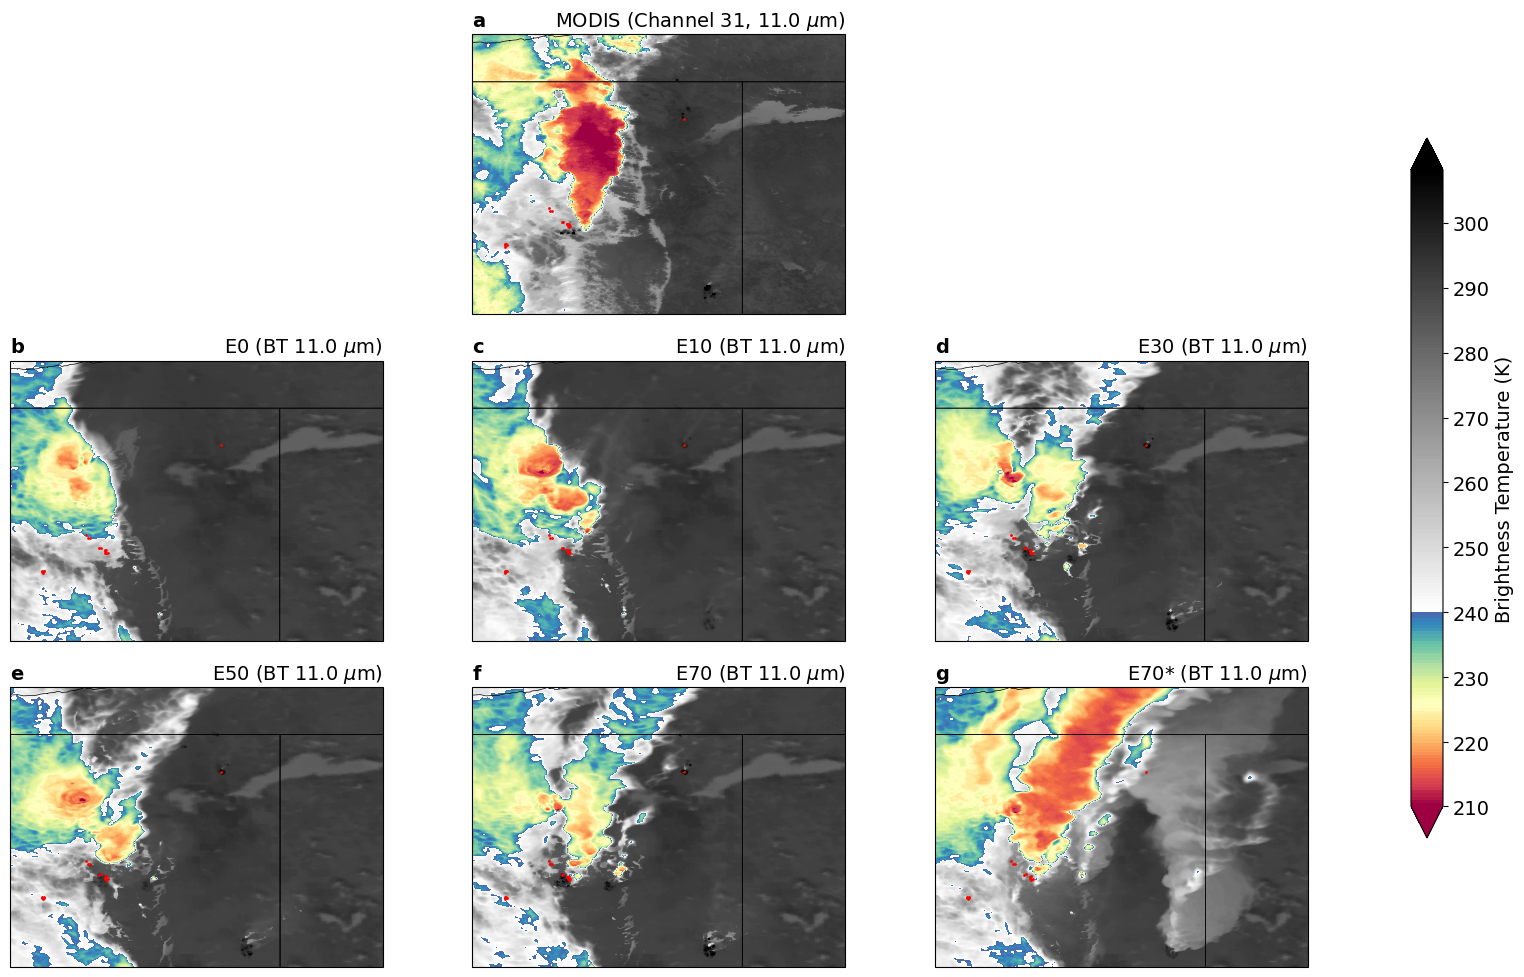

In [ ]:
# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, axes = plt.subplots(
    3,
    3,
    figsize=figsize,
    subplot_kw={"projection": map_projection},
)

axes = axes.ravel()

# -------------------------------------------------
# Blank panels
# -------------------------------------------------
axes[0].set_visible(False)
axes[2].set_visible(False)

# -------------------------------------------------
# MODIS
# -------------------------------------------------
c1 = axes[1].contourf(
    scene1.x,
    scene1.y,
    scene1.CHANNEL_31,
    levels=levels,
    transform=map_projection,
    cmap=cmap,
    extend="both",
)

axes[1].contourf(
    scene2.x,
    scene2.y,
    scene2.CHANNEL_31,
    levels=levels,
    transform=map_projection,
    cmap=cmap,
    extend="both",
)

axes[1].scatter(
    fire_lons,
    fire_lats,
    c=fire_color,
    s=fire_size,
)

axes[1].set_title(
    "MODIS (Channel 31, 11.0 $\mu$m)",
    loc="right",
)

axes[1].set_title(
    "a",
    loc="left",
    fontweight="bold",
)

axes[1].set_extent(
    [lon_min, lon_max, lat_min, lat_max]
)

# -------------------------------------------------
# Model runs
# -------------------------------------------------
syns = [syn1, syn2, syn3, syn4, syn5, syn6]

titles = [
    r"E0 (BT 11.0 $\mu$m)",
    r"E10 (BT 11.0 $\mu$m)",
    r"E30 (BT 11.0 $\mu$m)",
    r"E50 (BT 11.0 $\mu$m)",
    r"E70 (BT 11.0 $\mu$m)",
    r"E70* (BT 11.0 $\mu$m)",
]

panels = ["b", "c", "d", "e", "f", "g"]

for ax, syn, title, panel in zip(
    axes[3:],
    syns,
    titles,
    panels,
):
    ax.tricontourf(
        lon,
        lat,
        syn.bt110,
        levels=levels,
        transform=map_projection,
        cmap=cmap,
        extend="both",
    )

    ax.scatter(
        fire_lons,
        fire_lats,
        c=fire_color,
        s=fire_size,
    )

    ax.set_title(
        title,
        loc="right",
    )

    ax.set_title(
        panel,
        fontweight="bold",
        loc="left",
    )

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max]
    )

# -------------------------------------------------
# Map features
# -------------------------------------------------
for ax in axes:
    if not ax.get_visible():
        continue

    ax.coastlines(
        resolution=coastline_resolution,
        linewidth=coastline_linewidth,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=border_linewidth,
    )

    ax.add_feature(
        cfeature.STATES,
        linewidth=state_linewidth,
    )

# -------------------------------------------------
# Colorbar
# -------------------------------------------------
cax = fig.add_axes(colorbar_position)

cbar = fig.colorbar(
    c1,
    cax=cax,
    orientation="vertical",
    ticks=np.arange(210, 310, 10),
)

cbar.set_label(
    "Brightness Temperature (K)",
    fontsize=fs,
)

cbar.ax.tick_params(
    labelsize=fs,
)

# -------------------------------------------------
# Layout
# -------------------------------------------------
plt.tight_layout(
    rect=[0, 0, 0.9, 1]
)

plt.show()

fig.savefig(
    out_dir + "modis_map.png",
    dpi=300,
    bbox_inches="tight",
)